# 1. Setup & Imports

In [33]:
import pandas as pd
import numpy as np
import os
import hashlib
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

pd.set_option('display.max_columns', None)

# 2. Tabular Data (CSV) Audit

In [34]:
csv_path = '../data/raw/full_leish_data_2010-2022.csv'
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nColumn types:\n", df.dtypes)
df.head()

Shape: (156, 20)

Columns: ['    Annee', 'Mois', 'RH2M', 'TMP_MIN', 'TMP_MAX', 'WS2M', 'WS10M', 'WD10M', 'WD2M', 'UVA', 'UVB', 'CLOUD_AMT', 'SOIL_M', 'SOIL_W', 'SOIL_RW', 'PRECT_TOTAL', 'SURFACE_P', 'SH2M', 'Cases', 'Date']

Column types:
     Annee        int64
Mois             int64
RH2M           float64
TMP_MIN        float64
TMP_MAX        float64
WS2M           float64
WS10M          float64
WD10M          float64
WD2M           float64
UVA            float64
UVB            float64
CLOUD_AMT      float64
SOIL_M         float64
SOIL_W         float64
SOIL_RW        float64
PRECT_TOTAL    float64
SURFACE_P      float64
SH2M           float64
Cases            int64
Date               str
dtype: object


,Annee,Mois,RH2M,TMP_MIN,TMP_MAX,WS2M,WS10M,WD10M,WD2M,UVA,UVB,CLOUD_AMT,SOIL_M,SOIL_W,SOIL_RW,PRECT_TOTAL,SURFACE_P,SH2M,Cases,Date
0,2010,1,58.067647,-10.09,25.55,2.966471,4.247059,311.408235,311.491765,8.597647,0.148824,36.217647,0.527647,0.522941,0.534118,40.324706,83.640588,3.928235,71,2010-01-01
1,2010,2,67.925294,-5.69,26.46,3.704706,5.248235,274.142353,273.551765,9.837059,0.193529,54.170588,0.591765,0.614706,0.604706,83.442941,83.284706,5.432353,54,2010-02-01
2,2010,3,55.660000,-2.11,29.61,3.304118,4.689412,289.415294,288.811765,13.687647,0.314118,42.922941,0.602941,0.616471,0.621765,29.156471,83.697059,4.890000,48,2010-03-01
3,2010,4,49.796471,0.37,32.36,2.674118,3.782353,256.629412,250.105882,16.078824,0.385294,47.584706,0.518824,0.485294,0.527059,1.240588,83.464118,5.765882,20,2010-04-01
4,2010,5,41.630000,1.15,34.27,3.589412,4.928235,316.550000,313.687647,18.395882,0.453529,32.672353,0.462941,0.368824,0.466471,0.310000,83.564118,4.973529,17,2010-05-01


In [35]:
print("Missing values per column:\n", df.isnull().sum())
print("\n% missing:\n", (df.isnull().sum() / len(df) * 100).round(2))
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
     Annee      0
Mois           0
RH2M           0
TMP_MIN        0
TMP_MAX        0
WS2M           0
WS10M          0
WD10M          0
WD2M           0
UVA            0
UVB            0
CLOUD_AMT      0
SOIL_M         0
SOIL_W         0
SOIL_RW        0
PRECT_TOTAL    0
SURFACE_P      0
SH2M           0
Cases          0
Date           0
dtype: int64

% missing:
     Annee      0.0
Mois           0.0
RH2M           0.0
TMP_MIN        0.0
TMP_MAX        0.0
WS2M           0.0
WS10M          0.0
WD10M          0.0
WD2M           0.0
UVA            0.0
UVB            0.0
CLOUD_AMT      0.0
SOIL_M         0.0
SOIL_W         0.0
SOIL_RW        0.0
PRECT_TOTAL    0.0
SURFACE_P      0.0
SH2M           0.0
Cases          0.0
Date           0.0
dtype: float64

Duplicate rows: 0


In [36]:
df.describe(include='all')

,Annee,Mois,RH2M,TMP_MIN,TMP_MAX,WS2M,WS10M,WD10M,WD2M,UVA,UVB,CLOUD_AMT,SOIL_M,SOIL_W,SOIL_RW,PRECT_TOTAL,SURFACE_P,SH2M,Cases,Date
count,156.000000,156.00000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,156
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,2016.000000,6.50000,43.053511,1.201603,31.673269,2.631813,3.683482,248.386020,249.554113,13.993039,0.330984,31.322866,0.464702,0.342221,0.465946,121.674962,83.729031,4.920709,31.967949,NaN
std,3.753708,3.46317,12.526672,6.591168,6.758056,0.482511,0.622738,70.293597,65.979048,3.916059,0.138949,9.456710,0.044365,0.138211,0.049989,226.065183,0.277707,1.154036,34.555504,NaN
min,2010.000000,1.00000,18.688235,-10.090000,19.620000,1.447059,2.167647,20.964118,35.437647,7.709412,0.115882,12.635294,0.425882,0.087059,0.421176,0.000000,83.025294,2.550588,1.000000,NaN
25%,2013.000000,3.75000,32.949118,-4.420000,25.550000,2.348125,3.315110,203.870000,205.494167,9.931765,0.189559,24.763382,0.432647,0.219412,0.429412,3.589265,83.573824,4.072794,7.000000,NaN
50%,2016.000000,6.50000,44.150882,-0.455000,31.490000,2.619020,3.691397,268.489583,262.899412,14.203235,0.340588,30.879412,0.448235,0.362941,0.448529,20.783824,83.723235,4.940882,19.000000,NaN
75%,2019.000000,9.25000,52.852941,7.062500,38.182500,2.928235,4.033824,307.346495,305.658529,17.571029,0.453676,37.793971,0.480882,0.446324,0.486176,106.772500,83.922500,5.691029,47.250000,NaN


In [37]:
date_col = 'Date'
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

print("Date range:", df[date_col].min(), "to", df[date_col].max())
print("\nRows per year:")
print(df[date_col].dt.year.value_counts().sort_index())
print("\nInvalid/missing dates:", df[date_col].isnull().sum())

Date range: 2010-01-01 00:00:00 to 2022-12-01 00:00:00

Rows per year:
Date
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
Name: count, dtype: int64

Invalid/missing dates: 0


count    156.000000
mean      31.967949
std       34.555504
min        1.000000
25%        7.000000
50%       19.000000
75%       47.250000
max      172.000000
Name: Cases, dtype: float64


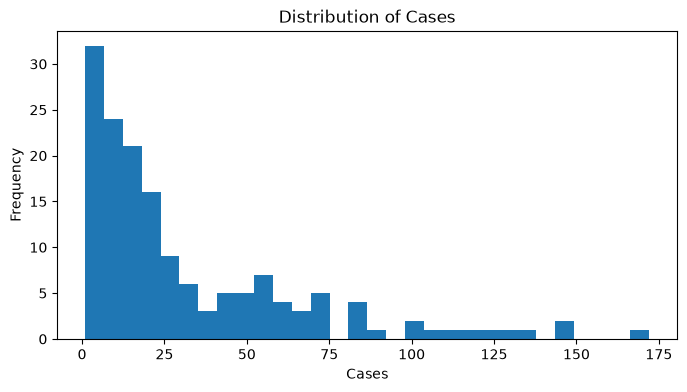

In [38]:
label_col = 'Cases'
print(df[label_col].describe())

plt.figure(figsize=(8,4))
df[label_col].plot(kind='hist', bins=30)
plt.title('Distribution of Cases')
plt.xlabel('Cases')
plt.show()

# 3. Distribution Analysis

Numeric columns: ['    Annee', 'Mois', 'RH2M', 'TMP_MIN', 'TMP_MAX', 'WS2M', 'WS10M', 'WD10M', 'WD2M', 'UVA', 'UVB', 'CLOUD_AMT', 'SOIL_M', 'SOIL_W', 'SOIL_RW', 'PRECT_TOTAL', 'SURFACE_P', 'SH2M', 'Cases']


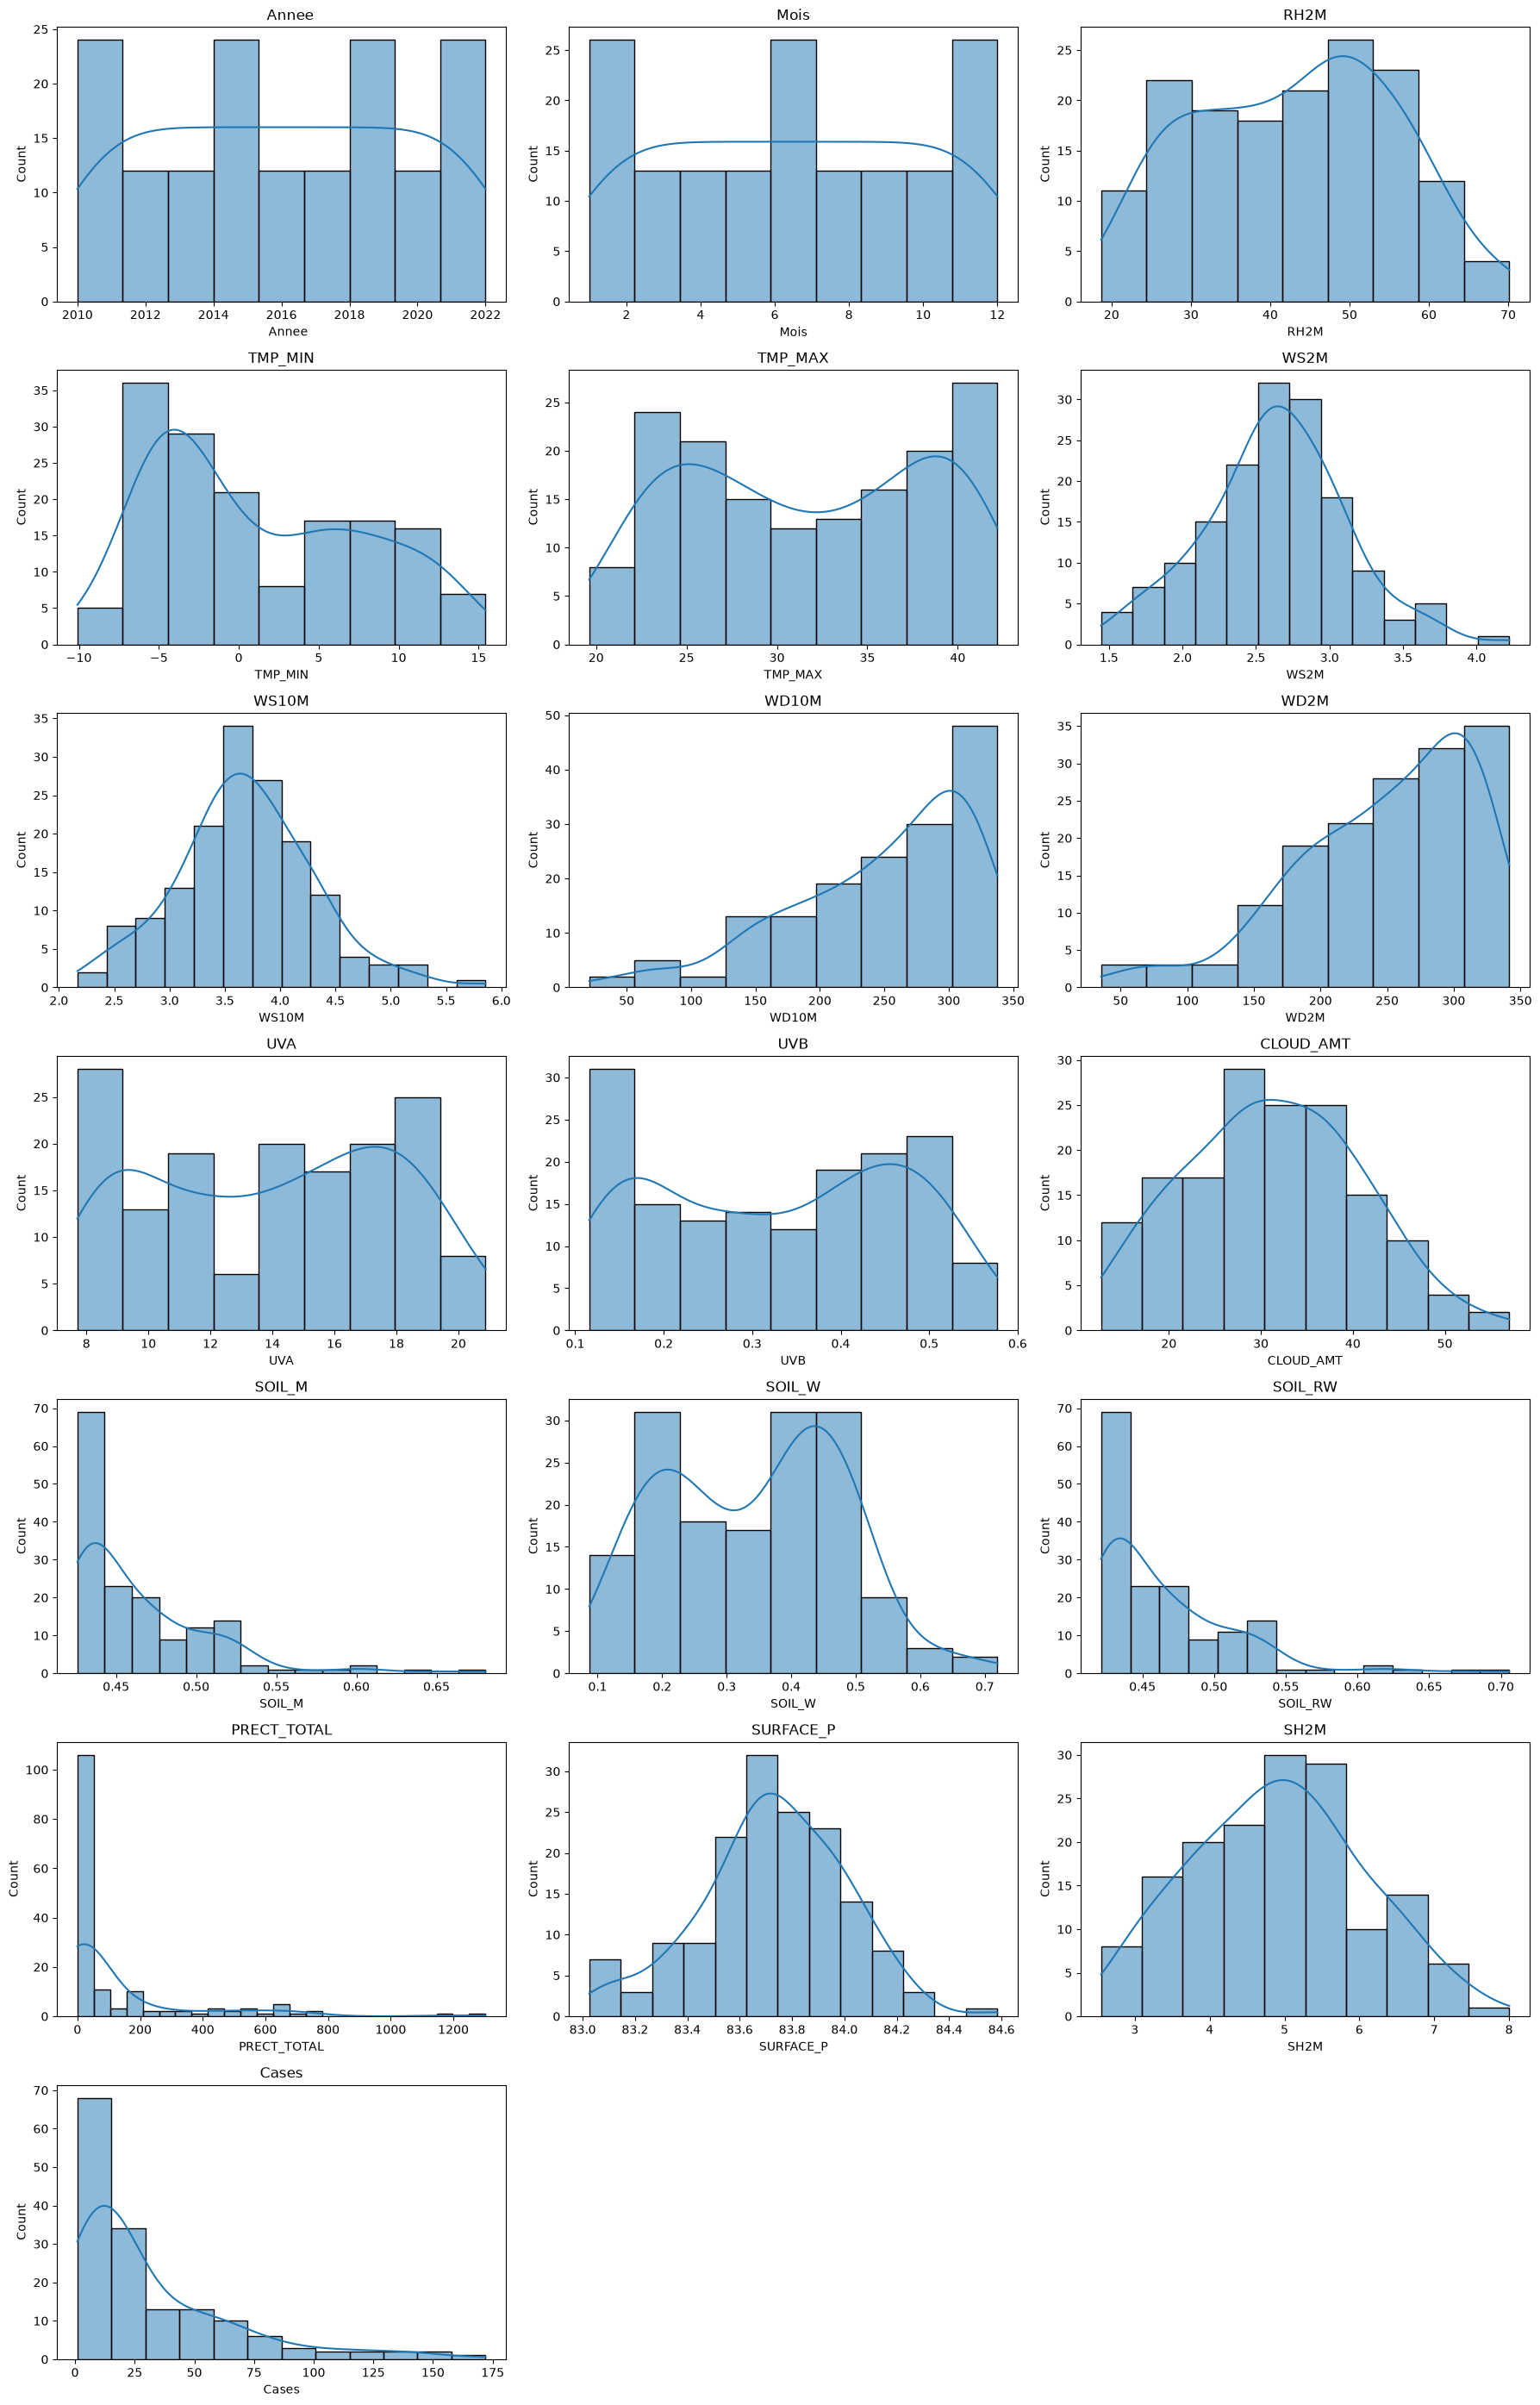

In [39]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

ncols = 3
nrows = (len(numeric_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [40]:
skew_kurt = pd.DataFrame({
    'skewness': df[numeric_cols].skew(),
    'kurtosis': df[numeric_cols].kurtosis()
}).sort_values('skewness', ascending=False)
print(skew_kurt)

             skewness  kurtosis
PRECT_TOTAL  2.629735  7.667600
SOIL_M       1.974197  5.200297
SOIL_RW      1.924124  4.971391
Cases        1.755024  2.952299
TMP_MIN      0.430535 -1.072973
WS10M        0.245991  0.674542
SH2M         0.144756 -0.491244
CLOUD_AMT    0.133427 -0.476103
SOIL_W       0.088198 -0.809689
WS2M         0.087882  0.402009
    Annee    0.000000 -1.214653
Mois         0.000000 -1.217232
RH2M        -0.018294 -0.933237
TMP_MAX     -0.030866 -1.411257
UVB         -0.056174 -1.404728
UVA         -0.068795 -1.323890
SURFACE_P   -0.197340  0.203594
WD2M        -0.904934  0.443224
WD10M       -0.957609  0.318366


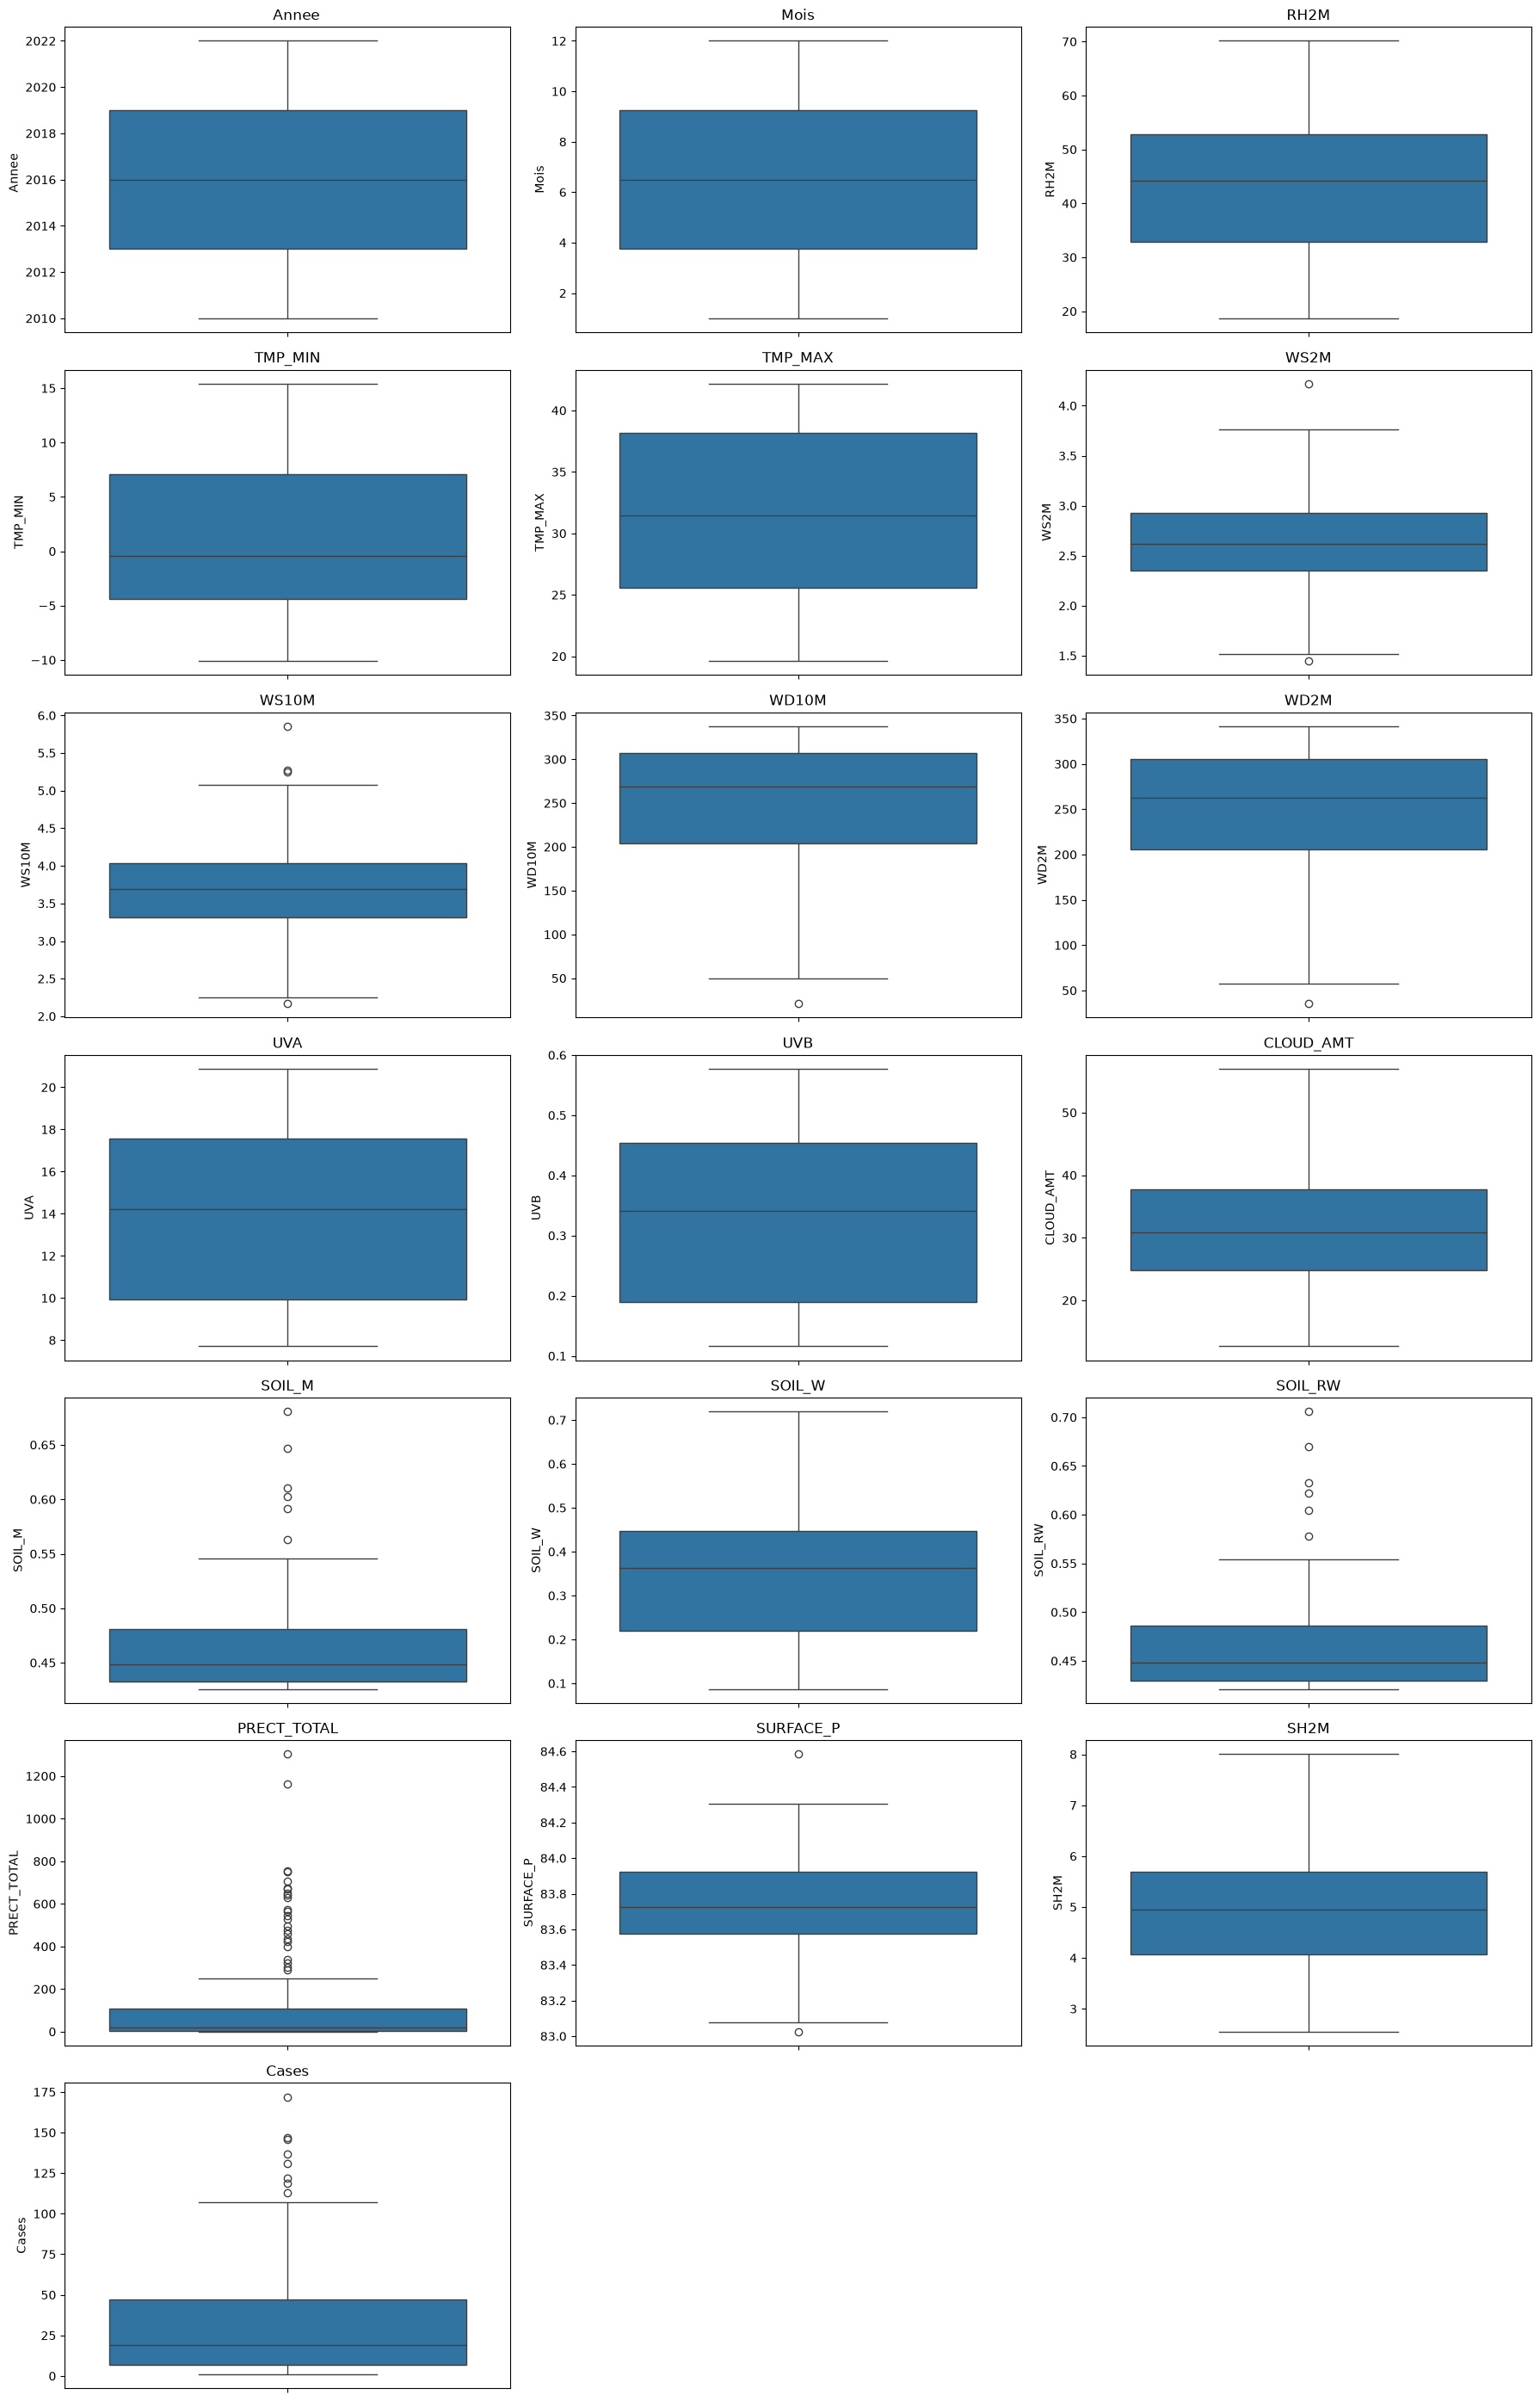

In [41]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 4. Correlation Analysis

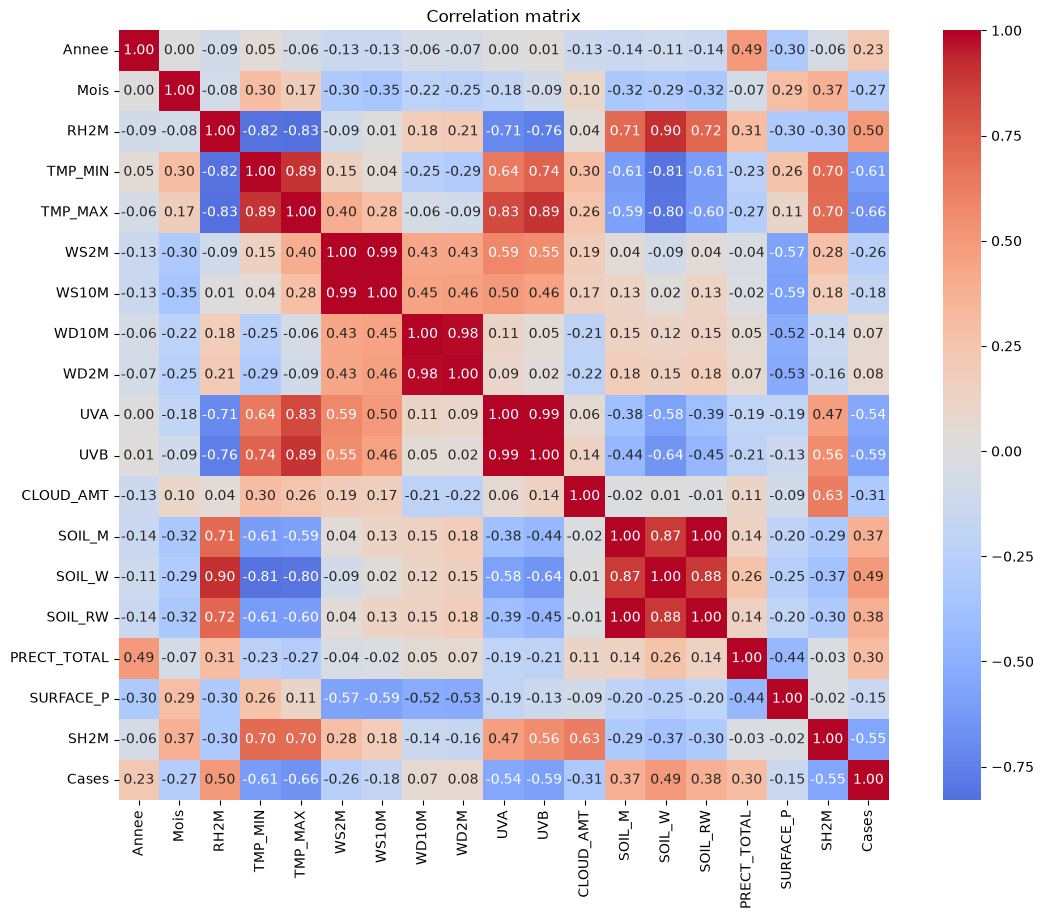

Correlation with Cases:

Cases          1.000000
RH2M           0.501877
SOIL_W         0.492616
SOIL_RW        0.376290
SOIL_M         0.374093
PRECT_TOTAL    0.301153
    Annee      0.227403
WD2M           0.082449
WD10M          0.065390
SURFACE_P     -0.147421
WS10M         -0.178516
WS2M          -0.255217
Mois          -0.267533
CLOUD_AMT     -0.311142
UVA           -0.542411
SH2M          -0.552716
UVB           -0.593708
TMP_MIN       -0.613812
TMP_MAX       -0.655174
Name: Cases, dtype: float64


In [42]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix')
plt.show()

print("Correlation with Cases:\n")
print(corr['Cases'].sort_values(ascending=False))

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [c for c in numeric_cols if c != 'Cases']
X_vif = df[vif_features].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

        feature            VIF
0         Annee  157208.504783
16    SURFACE_P  154521.880003
12       SOIL_M   75032.278404
14      SOIL_RW   64411.320449
6         WS10M   17792.465986
5          WS2M   16810.709750
9           UVA    2148.818721
10          UVB    1391.394223
4       TMP_MAX     748.206446
8          WD2M     482.932513
7         WD10M     407.192051
2          RH2M     344.001888
17         SH2M     294.008510
13       SOIL_W     225.556002
11    CLOUD_AMT      31.488678
3       TMP_MIN      16.111228
1          Mois      10.503428
15  PRECT_TOTAL       2.474604


# 5. PCA

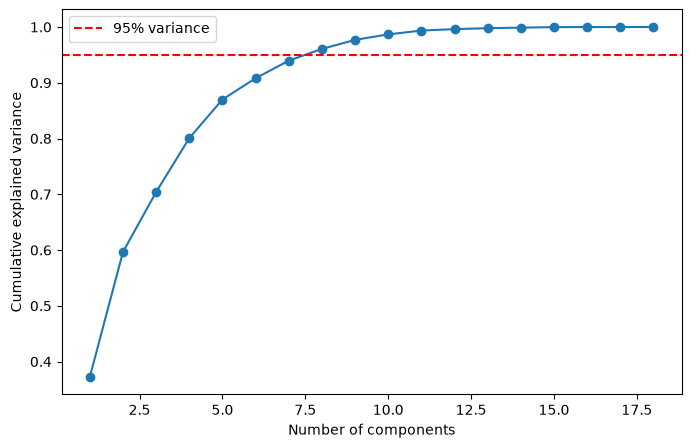

Components needed for 95% variance: 8


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [c for c in numeric_cols if c != 'Cases']
X_pca = df[pca_features].dropna()
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA()
pca.fit(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.show()

print("Components needed for 95% variance:", np.argmax(explained >= 0.95) + 1)

# 6. Image Dataset Audit

         class  count
0      Babesia   1173
1   Leishmania   2701
2    Leukocyte   1376
3   Plasmodium    843
4         RBCs   8995
5   Toxoplasma   6691
6  Trichomonad  10134
7  Trypanosome   2385

Total images: 34298


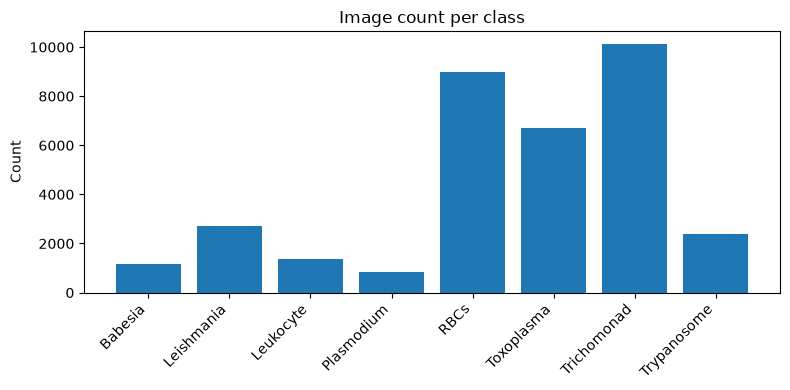

In [45]:
image_root = Path('../data/raw/parasite-dataset')

summary = []
for cls_dir in sorted(image_root.iterdir()):
    if cls_dir.is_dir():
        files = [f for f in cls_dir.glob('*') if f.is_file()]
        summary.append({'class': cls_dir.name, 'count': len(files)})

img_df = pd.DataFrame(summary)
print(img_df)
print("\nTotal images:", img_df['count'].sum())

plt.figure(figsize=(8,4))
plt.bar(img_df['class'], img_df['count'])
plt.title('Image count per class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [46]:
corrupted = []
all_images = [p for p in image_root.rglob('*') if p.is_file() and p.suffix.lower() != '.md']

for img_path in tqdm(all_images):
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception:
        corrupted.append(str(img_path))

print(f"Corrupted images found: {len(corrupted)}")
if corrupted:
    print(corrupted[:10])

100%|██████████| 34298/34298 [09:10<00:00, 62.26it/s] 

Corrupted images found: 0


In [47]:
sizes = []
formats = []
for cls_dir in image_root.iterdir():
    if cls_dir.is_dir():
        for img_path in list(cls_dir.glob('*'))[:50]:
            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
                    formats.append(img.format)
            except Exception:
                pass

size_df = pd.DataFrame(sizes, columns=['width', 'height'])
print("Unique sizes found:", size_df.drop_duplicates().shape[0])
print(size_df.describe())
print("\nFormats found:", set(formats))

Unique sizes found: 388
            width      height
count  400.000000  400.000000
mean   232.475000  226.762500
std    131.343642  120.799285
min     36.000000   38.000000
25%    155.000000  155.000000
50%    200.500000  200.000000
75%    300.000000  305.500000
max    889.000000  670.000000

Formats found: {'JPEG'}


In [48]:
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []
for img_path in tqdm(all_images):
    h = file_hash(img_path)
    if h in hashes:
        duplicates.append((str(img_path), hashes[h]))
    else:
        hashes[h] = str(img_path)

print(f"Duplicate images found: {len(duplicates)}")
if duplicates:
    print(duplicates[:5])

100%|██████████| 34298/34298 [00:11<00:00, 2908.75it/s]

Duplicate images found: 2470
[('..\\data\\raw\\parasite-dataset\\Leukocyte\\2_0000437.png', '..\\data\\raw\\parasite-dataset\\Leukocyte\\2_0000289.png'), ('..\\data\\raw\\parasite-dataset\\Leukocyte\\Tcell_0000003.jpg', '..\\data\\raw\\parasite-dataset\\Leukocyte\\Tcell_0000000.jpg'), ('..\\data\\raw\\parasite-dataset\\Leukocyte\\Tcell_0000004.jpg', '..\\data\\raw\\parasite-dataset\\Leukocyte\\Tcell_0000001.jpg'), ('..\\data\\raw\\parasite-dataset\\Leukocyte\\Tcell_0000005.jpg', '..\\data\\raw\\parasite-dataset\\Leukocyte\\Tcell_0000002.jpg'), ('..\\data\\raw\\parasite-dataset\\RBCs\\2_0.jpg', '..\\data\\raw\\parasite-dataset\\RBCs\\1000mcell_train.jpg')]


# 7. Data Augmentation

ModuleNotFoundError: No module named 'torchvision'